In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
## single genes
def genes_bootstrap(expr_dir, model_no_list, gene_name):
    gene_ranks = []
    for model_no in model_no_list:
        model_path = os.path.join(expr_dir, f"model_no_{model_no}_n1000_iter20.csv")
        ranks = pd.read_csv(model_path)
        gene_rank = ranks[ranks['gene']==gene_name]
        # gene_rank = list(gene_rank.values.squeeze()[1:-1])
        gene_rank = list(gene_rank.values.squeeze()[1:])
        gene_ranks.extend(gene_rank)
    
    return gene_ranks

In [14]:
def adjacent_values(vals, q1, q3):
    upper_adjacent_value = q3 + (q3 - q1) * 1.5
    upper_adjacent_value = np.clip(upper_adjacent_value, q3, vals[-1])

    lower_adjacent_value = q1 - (q3 - q1) * 1.5
    lower_adjacent_value = np.clip(lower_adjacent_value, vals[0], q1)
    return lower_adjacent_value, upper_adjacent_value


def plot_distr(ax, gene_ranks, color):
    parts = ax.violinplot(
        gene_ranks, showmeans=False, showmedians=False,
        showextrema=False)
    
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_edgecolor('black')
        pc.set_alpha(1)
    
    quartile1, medians, quartile3 = np.percentile(gene_ranks, [25, 50, 75])
    mean = np.mean(gene_ranks)
    whiskers = np.array([
        adjacent_values(gene_ranks, quartile1, quartile3)])
    whiskers_min, whiskers_max = whiskers[:, 0], whiskers[:, 1]

    ax.scatter([1], mean, marker='o', color='white', s=30, zorder=3)
    ax.vlines([1], quartile1, quartile3, color='k', linestyle='-', lw=5)
    ax.vlines([1], whiskers_min, whiskers_max, color='k', linestyle='-', lw=1)

    ax.set_ylim(0,1)
    ax.set_xticks([])

    return ax


DDR gene ranks

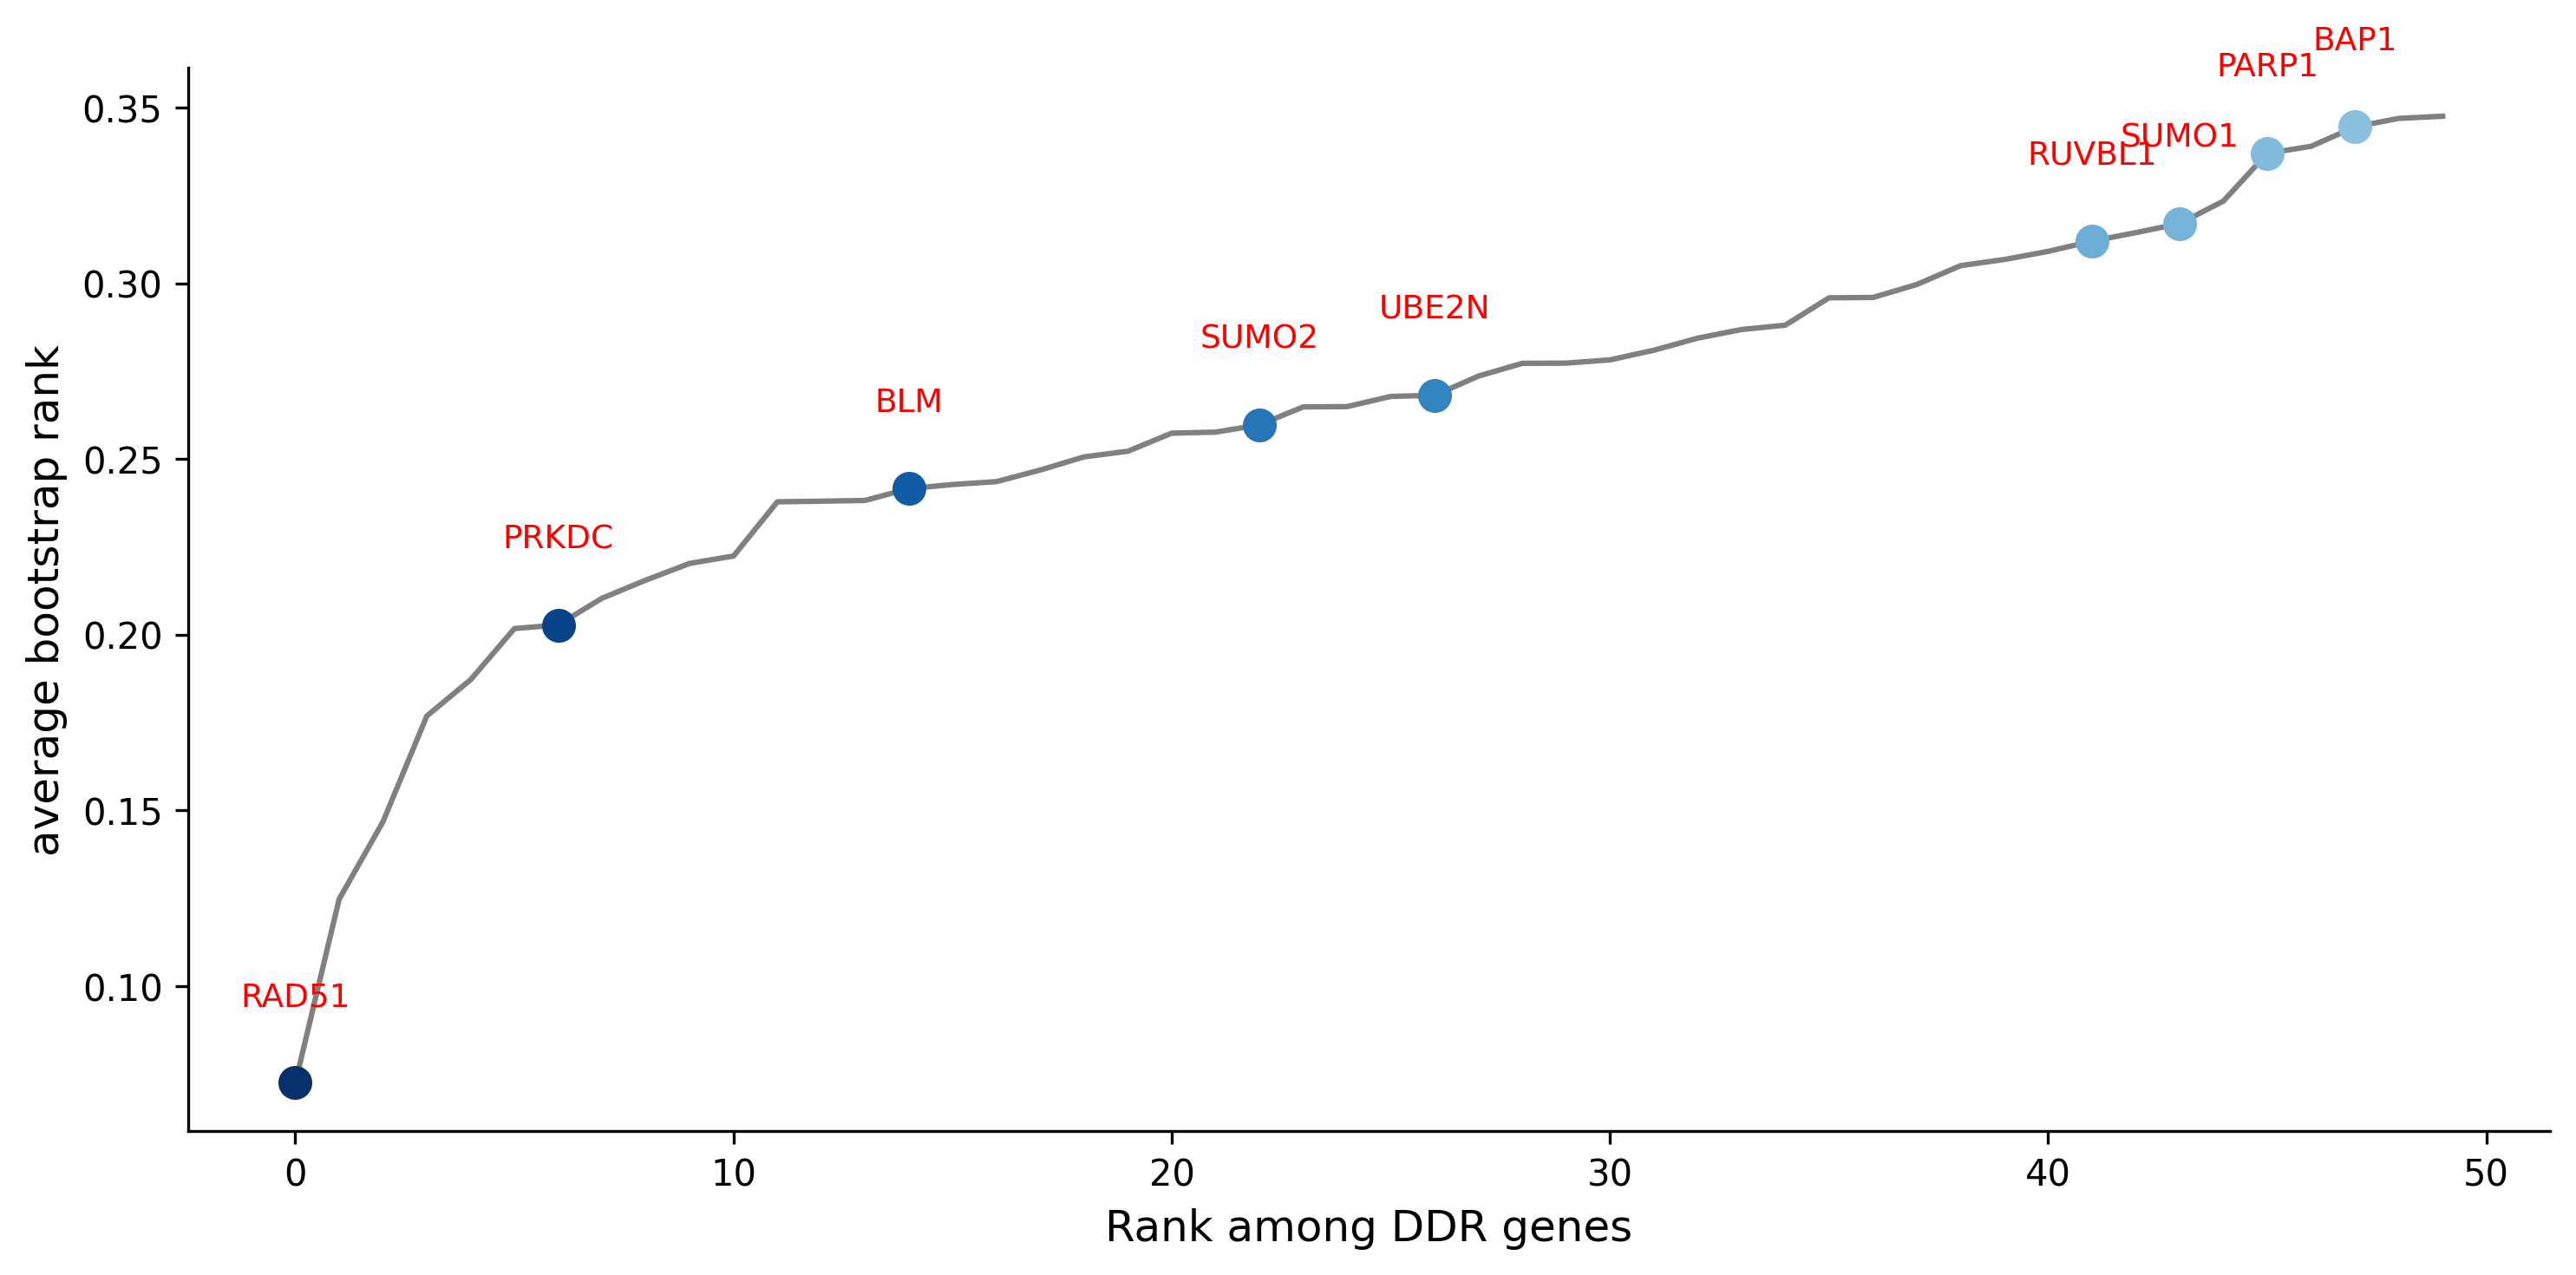

In [5]:
import matplotlib.cm as cm

ranks_df = pd.read_excel("../experiment/inference/IDH1_permute_inference_nonstratified/DDR_14th/modelno14_top50_iter20.xlsx")
colors = cm.Blues(np.linspace(1, 0.4, len(ranks_df)))

plt.figure(figsize=(10, 5), dpi=300)
plt.plot(range(len(ranks_df)), ranks_df['avg_rank'], color='gray')

# Annotate druggable genes
for i, row in ranks_df.iterrows():
    if row['druggable']:
        plt.scatter(ranks_df.index.get_loc(i), row['avg_rank'], color=colors[i], 
                    s=70, zorder=5, label='Druggable')
        plt.text(ranks_df.index.get_loc(i), row['avg_rank'] + 0.02, row['gene'],
                 ha='center', va='bottom', fontsize=9, color='red')

plt.xlabel("Rank among DDR genes", fontsize=12)
plt.ylabel("average bootstrap rank", fontsize=12)
plt.tight_layout()
ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

In [9]:
# Legend
size = 400  # size of the image (pixels)
cmap = cm.Blues
colors = cmap(np.linspace(1, 0.4, size))  # dark to light left-to-right

# Create a horizontal gradient image (size x size x 4)
gradient = np.tile(colors, (size, 1, 1))  # repeat across rows

# Create circular alpha mask
Y, X = np.ogrid[:size, :size]
center = size / 2
distance = np.sqrt((X - center)**2 + (Y - center)**2)
mask = distance <= (size / 2)
alpha = np.zeros((size, size))
alpha[mask] = 1

gradient[..., 3] = alpha  # set alpha channel

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(gradient, extent=[-1, 1, -1, 1])
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.close()

PRKDC, BCL2L1, PARP1

PRKDC 0.2026171875
BCL2L1 0.44416015625
PARP1 0.336640625


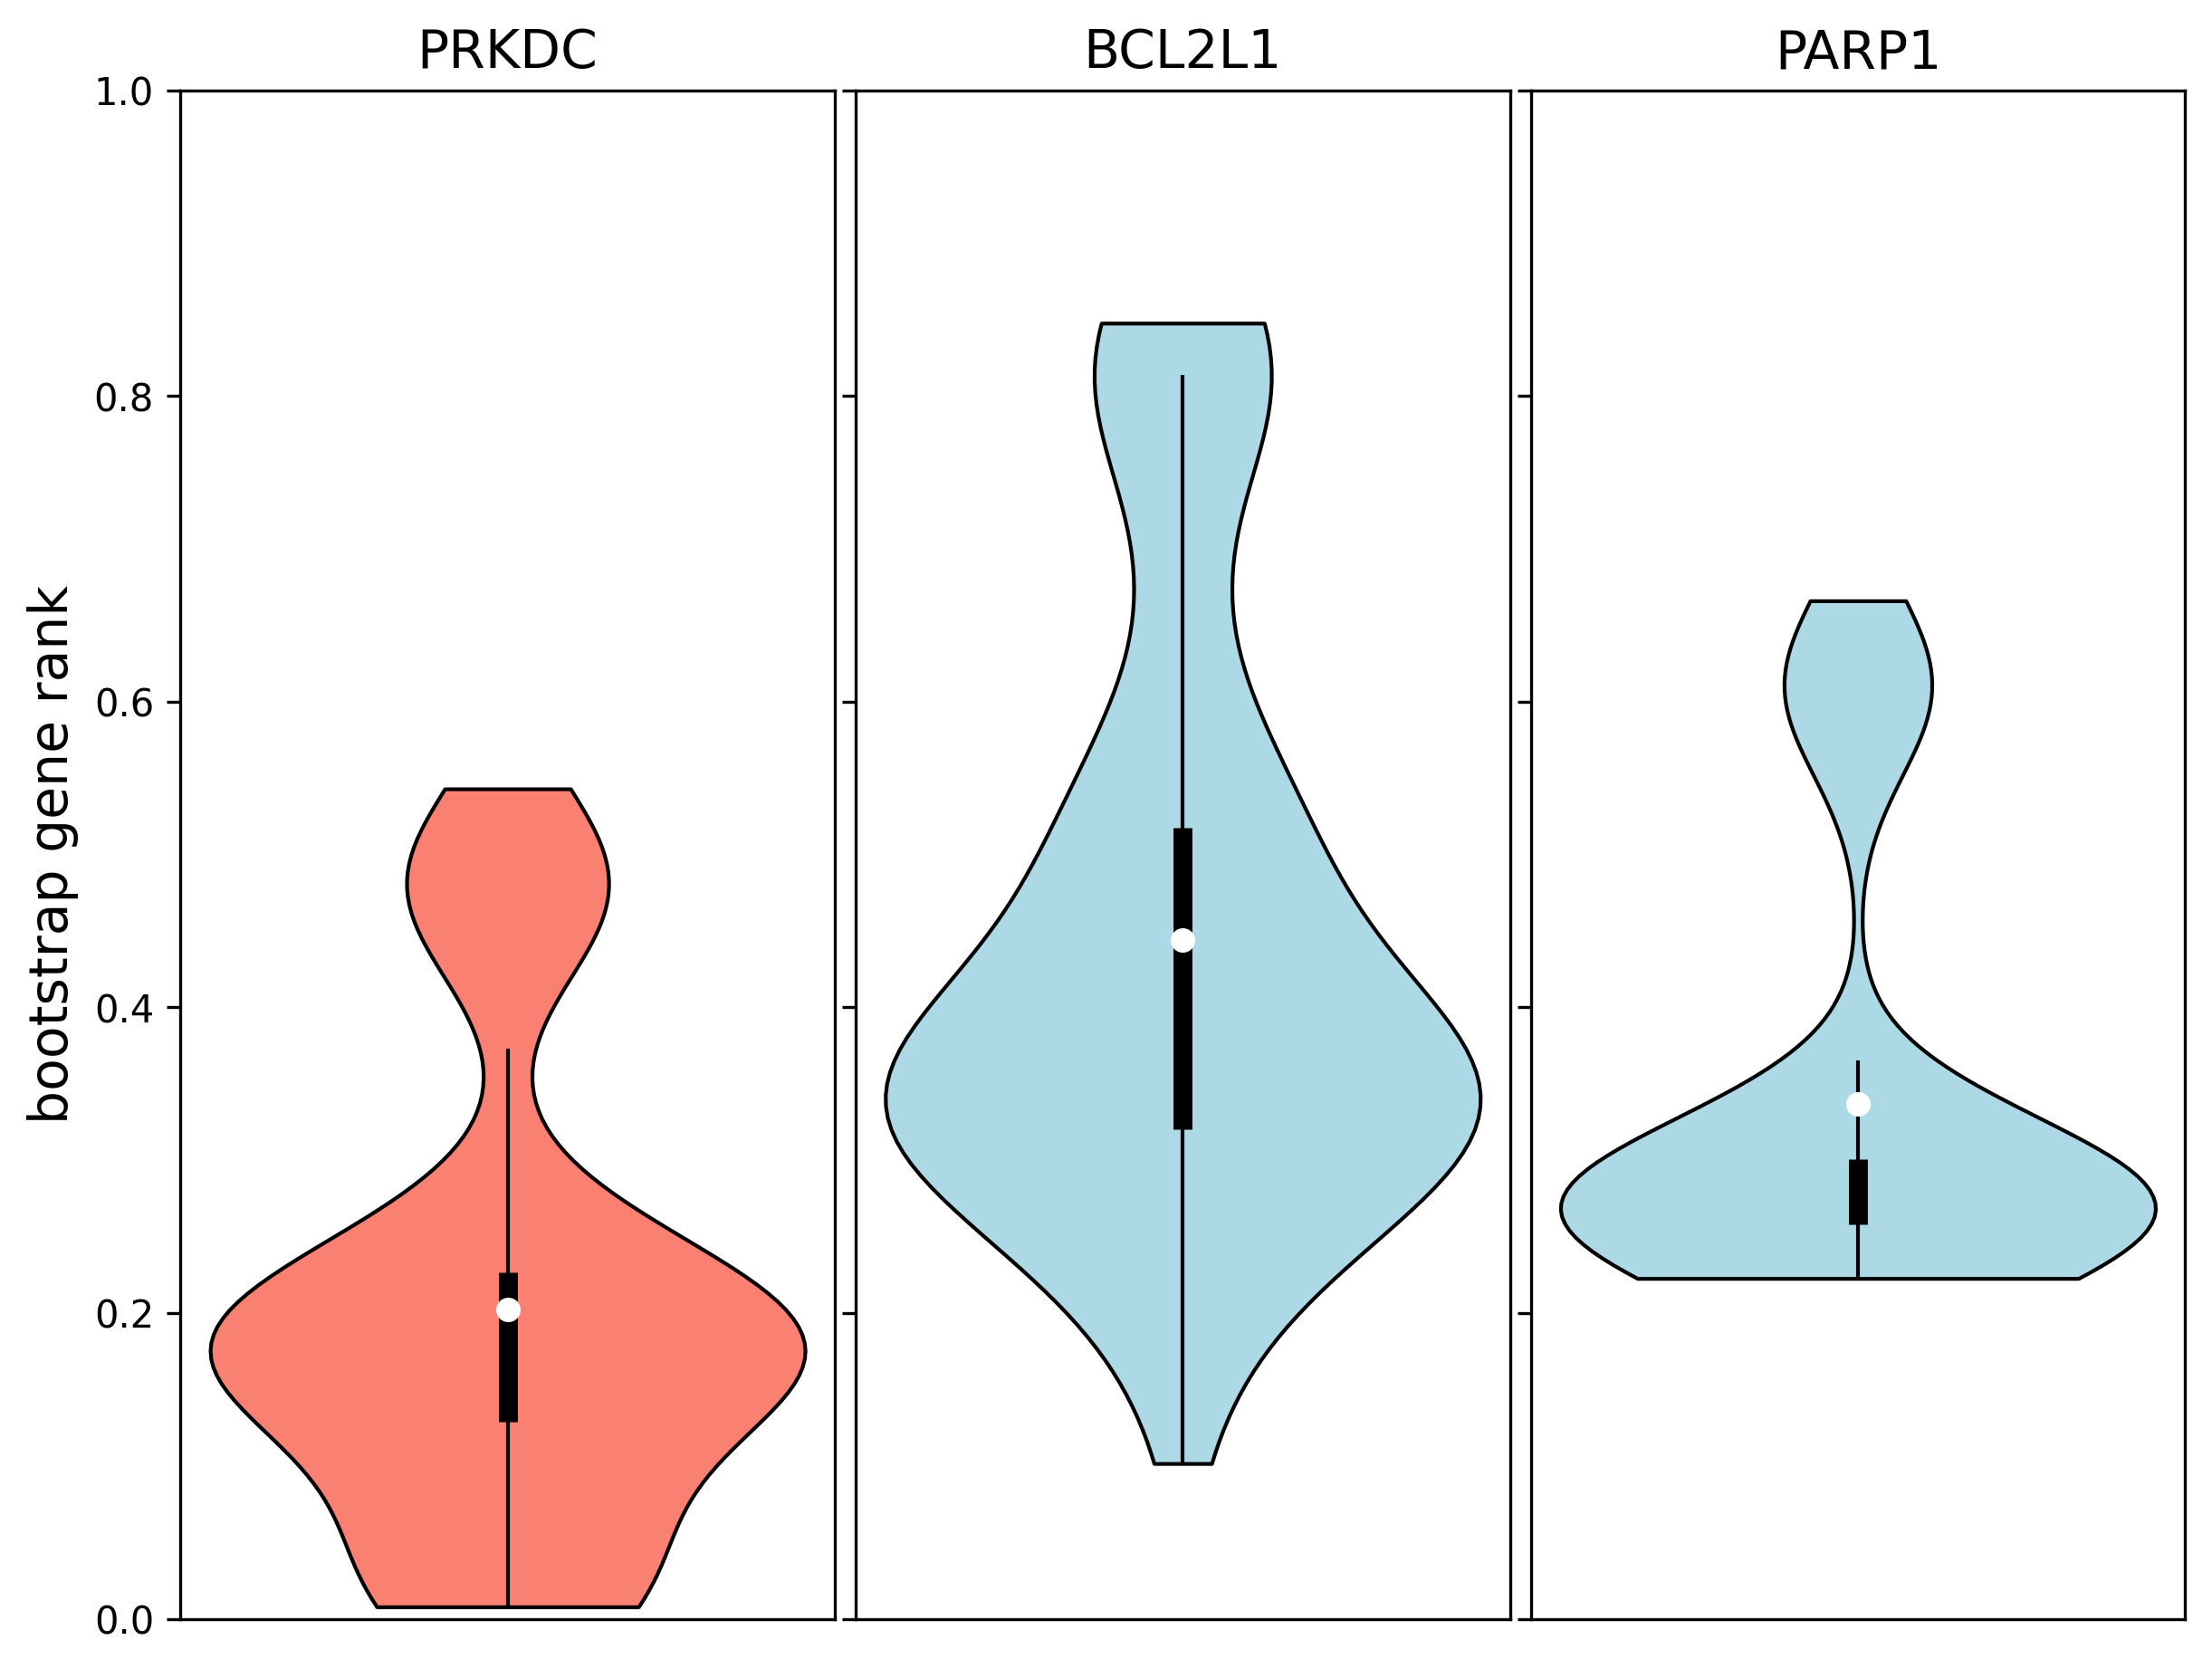

In [15]:
## multiple genes

fig, axs = plt.subplots(1,3, sharey=True, figsize=(8, 6), dpi=300)
for i, gene in enumerate(["PRKDC","BCL2L1","PARP1"]):
    prkdc_ranks = genes_bootstrap(
        expr_dir="../experiment/inference/IDH1_permute_inference_nonstratified/DDR_14th",
        model_no_list=[14],
        gene_name=gene
    )

    prkdc_ranks.sort()
    
    ax_color = "salmon" if gene=='PRKDC' else "lightblue"
    axs[i] = plot_distr(axs[i], prkdc_ranks, color=ax_color)
    print(gene, np.mean(prkdc_ranks))

    axs[i].set_title(f"{gene}", fontsize=14)
    axs[i].set_ylim(0,1)
    axs[i].set_xticks([])

axs[0].set_ylabel('bootstrap gene rank', fontsize=14)
fig.tight_layout(pad=0.2)

across multiple cancers

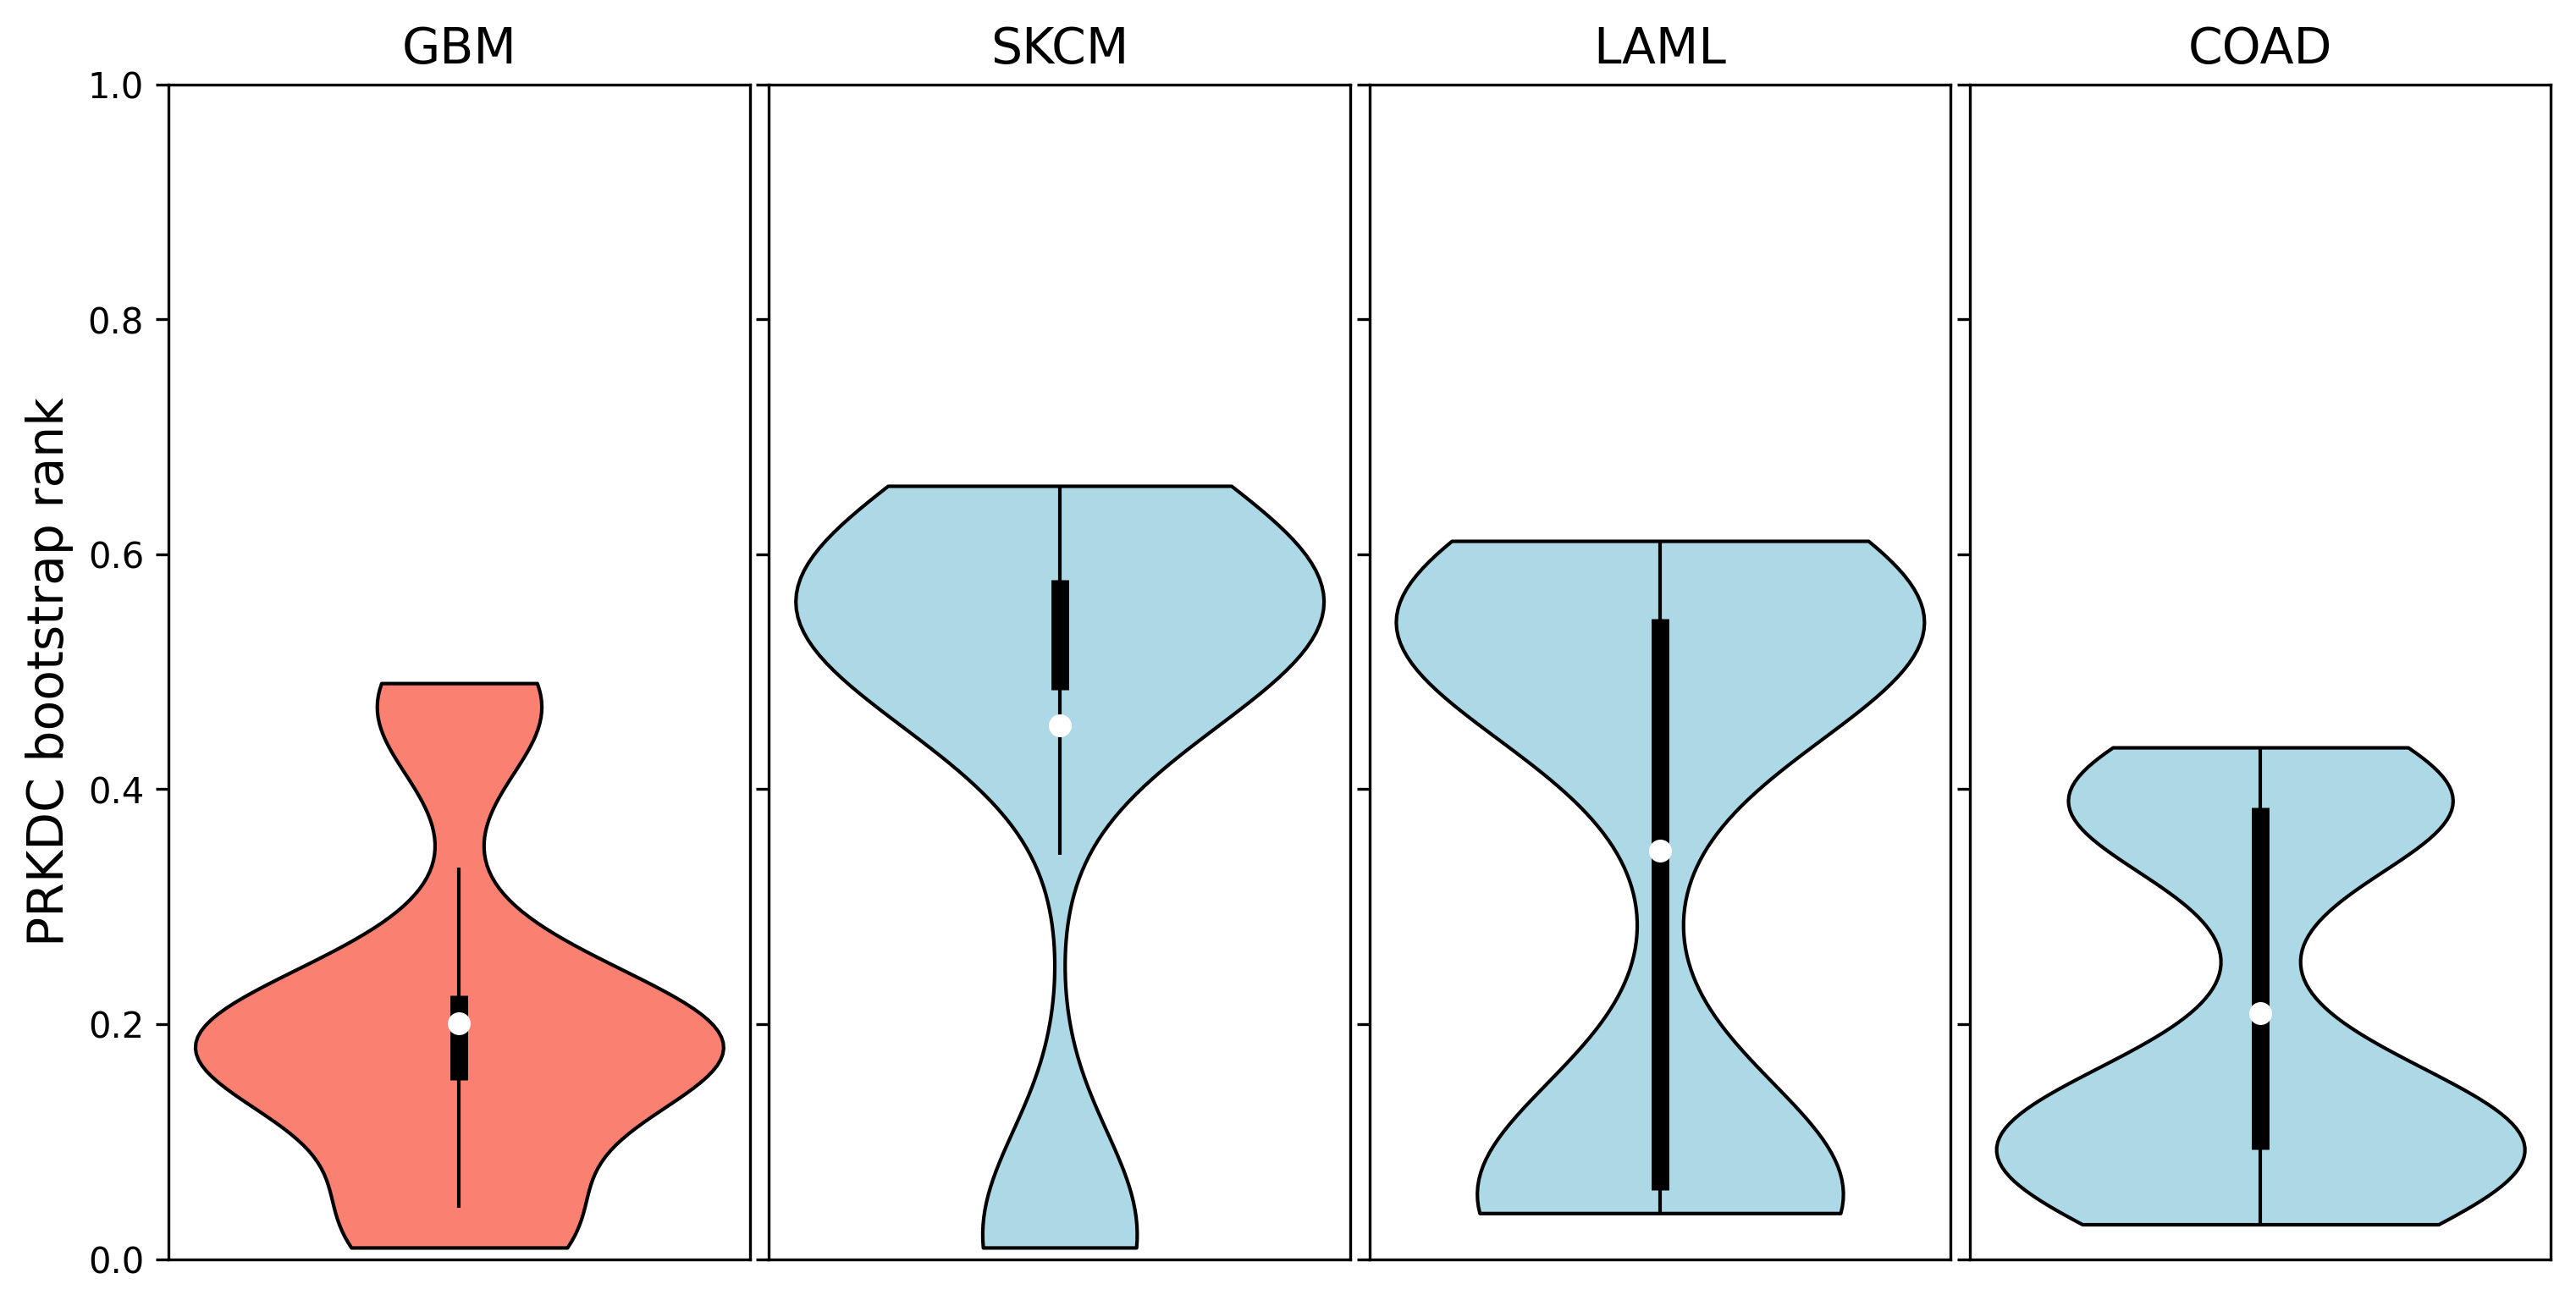

In [16]:
gene_name = "PRKDC"
cancer_list=['gbm', 'skcm', 'laml','coad']

fig, axs = plt.subplots(1,len(cancer_list), sharey=True, figsize=(10,5), dpi=300)
for i, cancer in enumerate(cancer_list):
    gene_ranks = genes_bootstrap(
        expr_dir=f"../experiment/inference/IDH1_permute_inference_nonstratified/multi-cancer-14th-{cancer}",
        model_no_list=[14],
        gene_name=gene_name,
    )
    gene_ranks.sort()
    
    ax_color = "salmon" if cancer=='gbm' else "lightblue"
    axs[i] = plot_distr(axs[i], gene_ranks, color=ax_color)
    axs[i].set_title(cancer.upper(), fontsize=14)

axs[0].set_ylabel(f'{gene_name} bootstrap rank', fontsize=14)
fig.tight_layout(pad=0.2)

distr across models

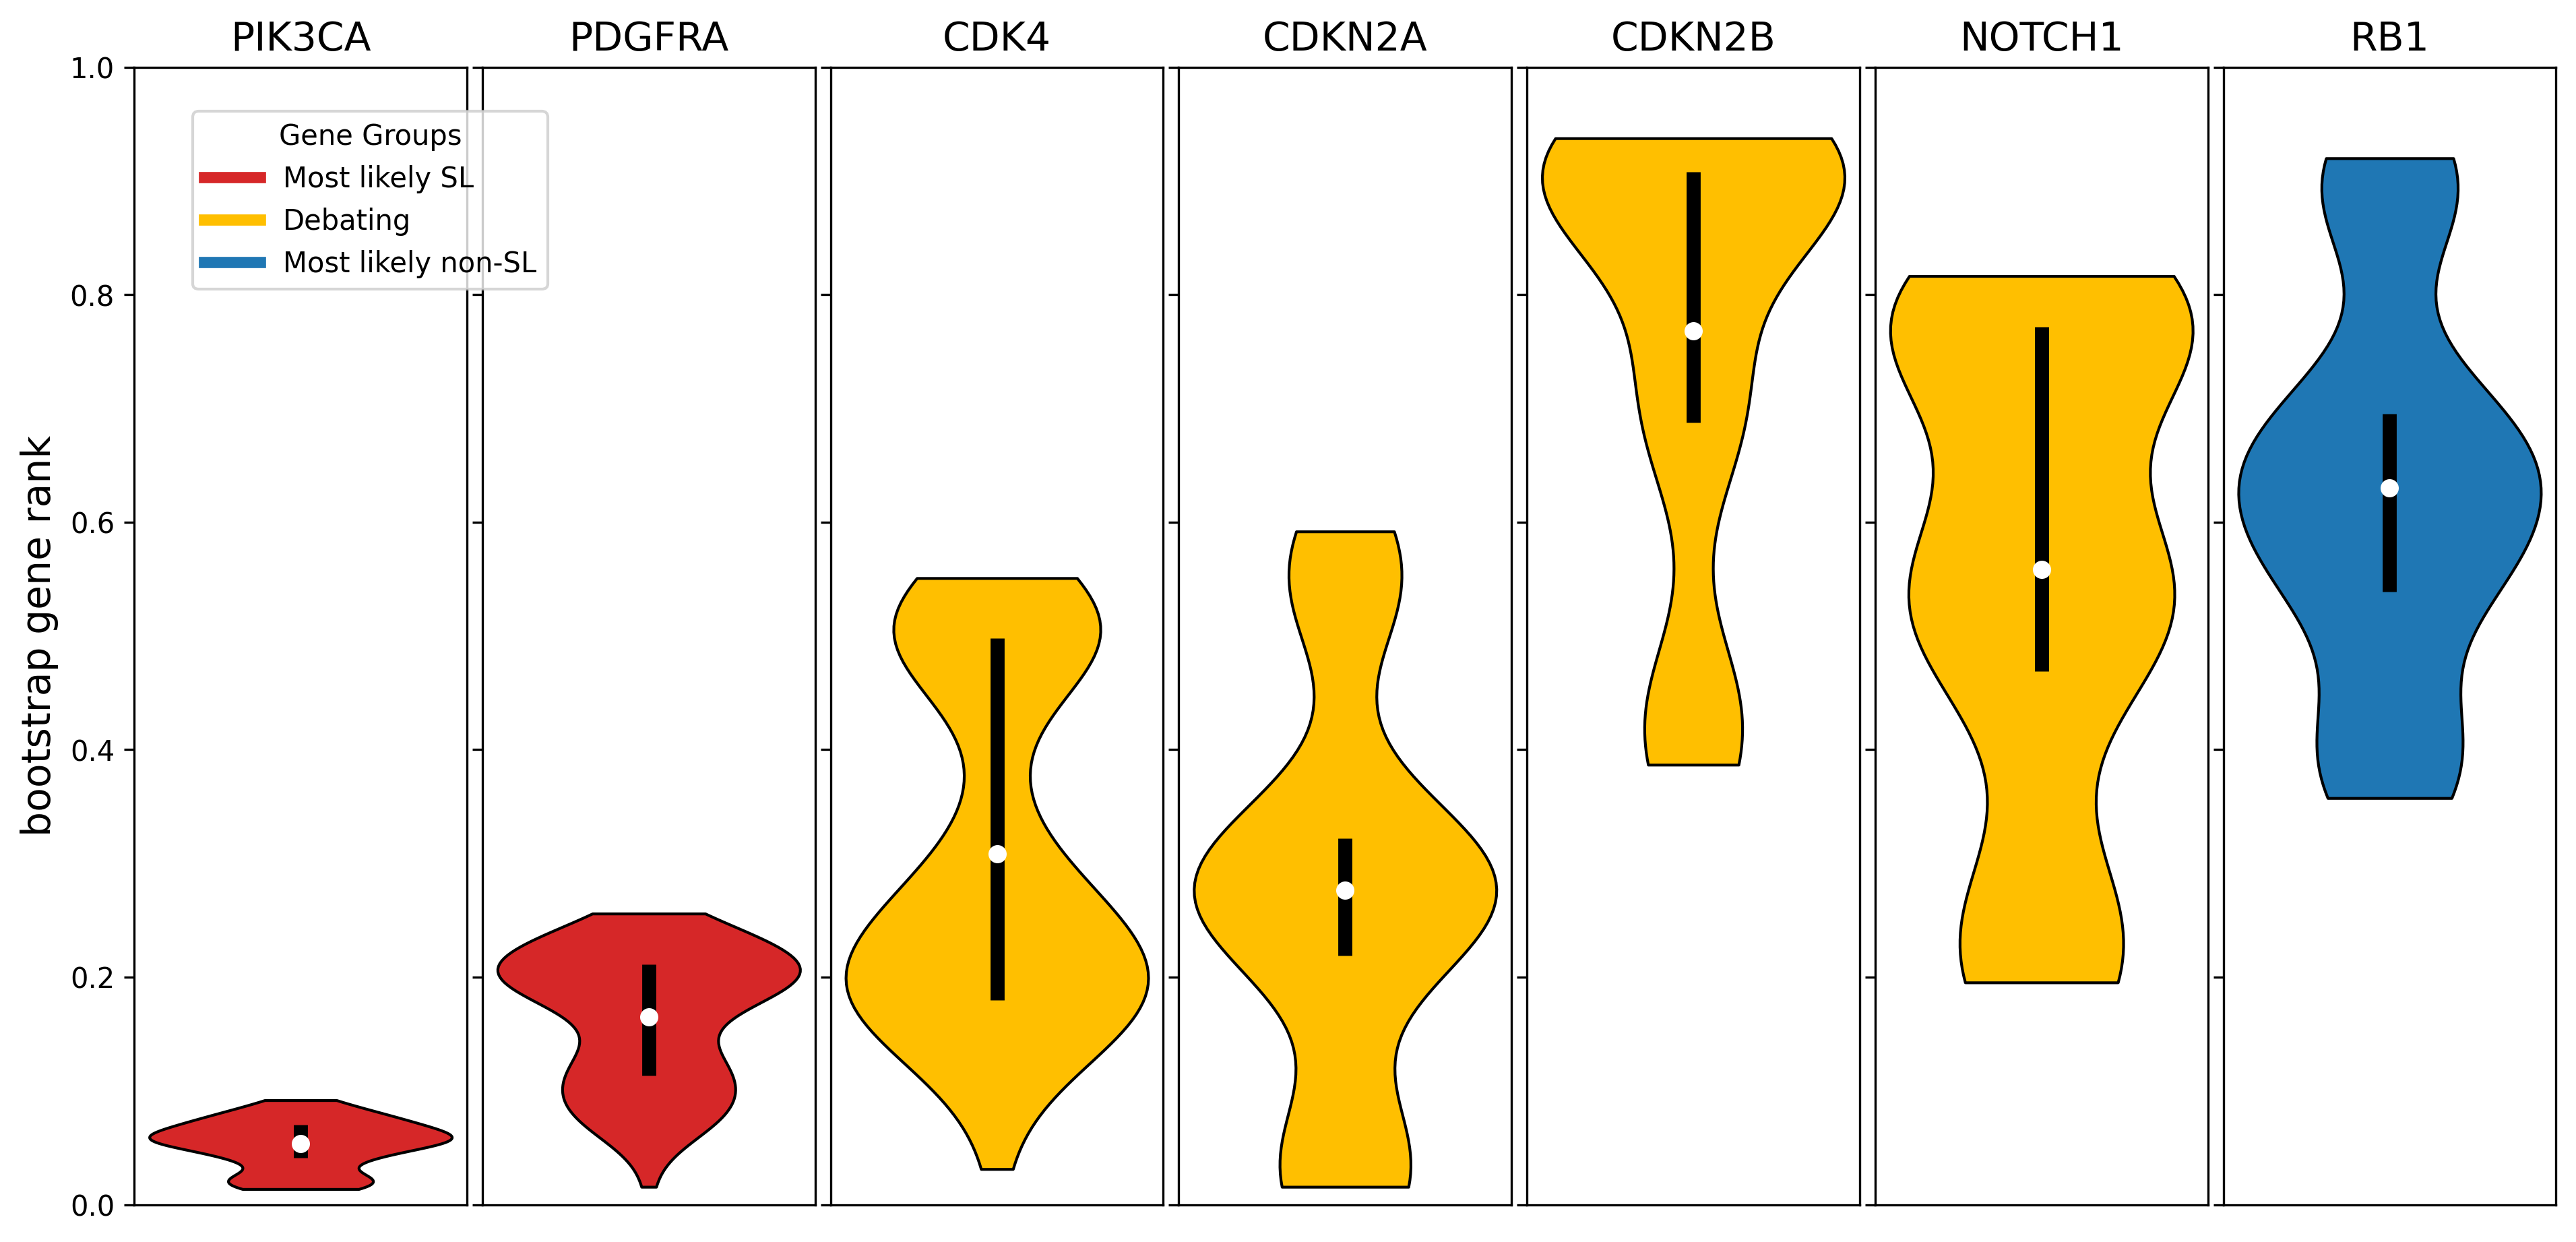

In [17]:
## 14th model
gene_list = ['PIK3CA', 'PDGFRA', 'CDK4', 'CDKN2A', 'CDKN2B', 'NOTCH1', 'RB1']
group_colors = {
    "Most likely SL": "#D62728",  # Red
    "Debating": "#FFBF00",  # Yellow
    "Most likely non-SL": "#1F77B4"   # Blue
}
colors = ["#D62728"]*2+["#FFBF00"]*4+["#1F77B4"]

fig, axs = plt.subplots(1,len(gene_list), sharey=True, figsize=(1.8*7,6), dpi=300)
for i, gene in enumerate(gene_list):
    gene_ranks = genes_bootstrap(
        expr_dir="../experiment/inference/IDH1_permute_inference_nonstratified/gbm_candidates_14th",
        model_no_list=[14],
        gene_name=gene
    )

    axs[i] = plot_distr(axs[i], gene_ranks, color=colors[i])
    axs[i].set_title(gene, fontsize=14)

axs[0].set_ylabel('bootstrap gene rank', fontsize=14)

handles = [plt.Line2D([0], [0], color=color, lw=4, label=group) for group, color in group_colors.items()]
fig.legend(handles=handles, title="Gene Groups", loc="upper left", bbox_to_anchor=(0.07, 0.92), borderaxespad=0)

fig.tight_layout(pad=0.2)